# 01 - Data Labelling

This notebook assigns clusters the data into different groupings and assigns labels to each row as 'No Risk', 'Severe Risk' and 'Moderate Risk'

### Imports and Data Load

In [23]:
import pandas as pd
import numpy as np
from sklearn.mixture import GaussianMixture
from scipy.stats import zscore
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

In [24]:
raw_data = pd.read_csv('../Data/raw.csv')

### Efficiency Score Calculation for Basic Numeric Tasks

In [25]:
efficiency_questions = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 
                        'Q7', 'Q8', 'Q9', 'Q10', 'Q11', 'Q24']

time_col_map = {
    'Q1': 'Q1_Time', 'Q2': 'Q2_Time', 'Q3': 'Q3_Time',
    'Q4': 'Q4_Time', 'Q5': 'Q5_Time', 'Q6': 'Q6_Time',
    'Q7': 'Q7_Time', 'Q8': 'Q8_Time', 'Q9': 'Q9_Time',
    'Q10': 'Q10_Time', 'Q11': 'Q11_Time', 'Q24': 'Q24_Time'
}

def calculate_efficiency(row, questions, time_map):
    correct_times = []
    correct_count = 0
    
    for q in questions:
        time_col = time_map[q]
        if row[q] >= 1:  # correct or partially correct
            correct_times.append(row[time_col])
            correct_count += 1
    
    if correct_count == 0:
        return np.nan  # no correct answers
    
    median_time = np.median(correct_times)
    return round(median_time / correct_count, 4)

raw_data['Efficiency_Score'] = raw_data.apply(
    lambda row: calculate_efficiency(row, efficiency_questions, time_col_map),
    axis=1
)

print('Efficiency Score:')
print(raw_data['Efficiency_Score'].describe())
print('NaNs:', raw_data['Efficiency_Score'].isna().sum())

Efficiency Score:
count    680.000000
mean       1.167286
std        0.994795
min        0.241700
25%        0.593000
50%        0.852050
75%        1.371725
max       11.302500
Name: Efficiency_Score, dtype: float64
NaNs: 0


### Score for Complex Questions

In [26]:
score_questions = ['Q12', 'Q13', 'Q14', 'Q15', 'Q16', 
                   'Q17', 'Q18', 'Q19', 'Q20', 'Q21', 
                   'Q22', 'Q23']


for col in score_questions:
    print(col, raw_data[col].unique())

Q12 [0.  0.5 1. ]
Q13 [0.  1.  0.5]
Q14 [1 0]
Q15 [0 1]
Q16 [0 1]
Q17 [1 0]
Q18 [1 0]
Q19 [0 1]
Q20 [1 0]
Q21 [0 1]
Q22 [1 0]
Q23 [1 0]


### T-Standardization

In [27]:
def to_t_score(series):
    z_scores = stats.zscore(series.fillna(series.mean()))
    return (z_scores * 10) + 50


feature_cols = ['Efficiency_Score'] + score_questions

cluster_df = raw_data[feature_cols].copy()

cluster_df_t = cluster_df.apply(to_t_score)

print('T-Score Statistics:')
print(cluster_df_t.describe().round(2))

# verify mean ~50 and SD ~10 for each column
print('\nMeans (should be ~50):')
print(cluster_df_t.mean().round(2))
print('\nSDs (should be ~10):')
print(cluster_df_t.std().round(2))

T-Score Statistics:
       Efficiency_Score     Q12     Q13     Q14     Q15     Q16     Q17  \
count            680.00  680.00  680.00  680.00  680.00  680.00  680.00   
mean              50.00   50.00   50.00   50.00   50.00   50.00   50.00   
std               10.01   10.01   10.01   10.01   10.01   10.01   10.01   
min               40.69   34.82   35.15   19.75   37.21   43.48   38.12   
25%               44.22   34.82   35.15   53.31   37.21   43.48   38.12   
50%               46.83   57.12   57.39   53.31   57.82   43.48   58.42   
75%               52.06   57.12   57.39   53.31   57.82   65.33   58.42   
max              151.96   57.12   57.39   53.31   57.82   65.33   58.42   

          Q18     Q19     Q20     Q21     Q22     Q23  
count  680.00  680.00  680.00  680.00  680.00  680.00  
mean    50.00   50.00   50.00   50.00   50.00   50.00  
std     10.01   10.01   10.01   10.01   10.01   10.01  
min     40.17   33.01   35.78   42.61   24.56   22.81  
25%     40.17   33.01   

### Fitting Gaussian Mixture Model

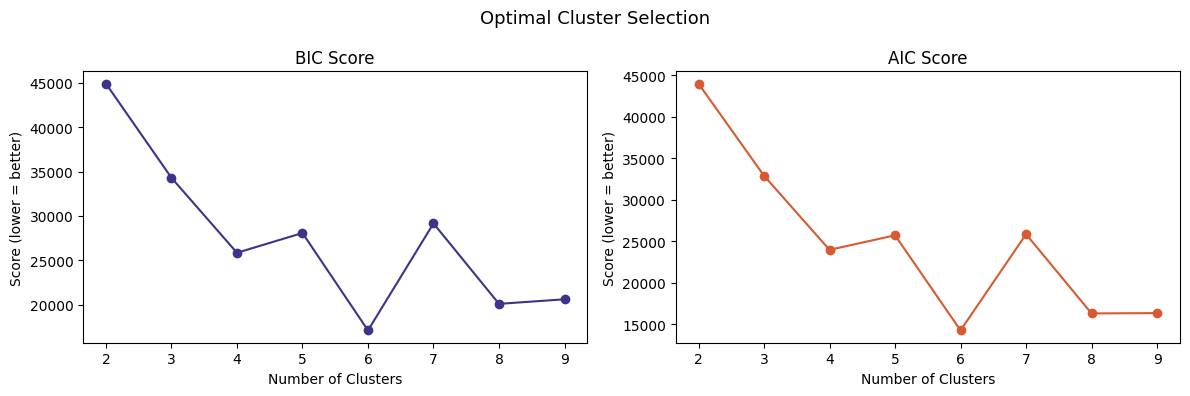

Optimal clusters (BIC): 6
Optimal clusters (AIC): 6


In [28]:


COLORS = ['#3C3489', '#0F6E56', '#185FA5', '#D85A30', '#BA7517']

X_cluster = cluster_df_t.values

bic_scores = []
aic_scores = []
n_range = range(2, 10)

for n in n_range:
    gmm = GaussianMixture(n_components=n, random_state=42, covariance_type='full')
    gmm.fit(X_cluster)
    bic_scores.append(gmm.bic(X_cluster))
    aic_scores.append(gmm.aic(X_cluster))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(n_range, bic_scores, marker='o', color=COLORS[0])
axes[0].set_title('BIC Score')
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('Score (lower = better)')

axes[1].plot(n_range, aic_scores, marker='o', color=COLORS[3])
axes[1].set_title('AIC Score')
axes[1].set_xlabel('Number of Clusters')
axes[1].set_ylabel('Score (lower = better)')

plt.suptitle('Optimal Cluster Selection', fontsize=13)
plt.tight_layout()
plt.show()

optimal_n = n_range[np.argmin(bic_scores)]
print(f'Optimal clusters (BIC): {optimal_n}')
print(f'Optimal clusters (AIC): {n_range[np.argmin(aic_scores)]}')

In [29]:
gmm_final = GaussianMixture(
    n_components=optimal_n, 
    random_state=42, 
    n_init=10,
    covariance_type='full'
)
gmm_final.fit(X_cluster)


raw_data['Cluster'] = gmm_final.predict(X_cluster)
raw_data['Cluster_Probability'] = gmm_final.predict_proba(X_cluster).max(axis=1)

# check cluster means on efficiency + total score
cluster_summary = raw_data.groupby('Cluster').agg(
    Count=('Cluster', 'count'),
    Avg_Efficiency=('Efficiency_Score', 'mean'),
    Avg_Total_Score=('Total Score', 'mean'),
    Std_Total_Score=('Total Score', 'std'),
    Std_Efficiency=('Efficiency_Score', 'std')
).sort_values('Avg_Total_Score')

print(cluster_summary.round(3))

         Count  Avg_Efficiency  Avg_Total_Score  Std_Total_Score  \
Cluster                                                            
4           70           1.611           11.100            4.456   
2           26           1.644           13.865            5.071   
5          117           1.592           13.953            6.789   
0           47           1.453           14.649            6.476   
1          209           0.996           19.533            6.369   
3          211           0.832           21.066            5.780   

         Std_Efficiency  
Cluster                  
4                 0.910  
2                 1.488  
5                 1.545  
0                 1.173  
1                 0.644  
3                 0.528  


### Grouping Similar Clusters

In [32]:
cluster_to_risk = {
    0: 'Moderate Risk',      
    1: 'No Risk',         
    2: 'Moderate Risk',        
    3: 'No Risk',
    4: 'Severe Risk',
    5: 'Moderate Risk'
}

raw_data['Risk_Label'] = raw_data['Cluster'].map(cluster_to_risk)

print('\nRisk Label Distribution:')
print(raw_data['Risk_Label'].value_counts())
print(raw_data['Risk_Label'].value_counts(normalize=True).mul(100).round(1))


Risk Label Distribution:
Risk_Label
No Risk          420
Moderate Risk    190
Severe Risk       70
Name: count, dtype: int64
Risk_Label
No Risk          61.8
Moderate Risk    27.9
Severe Risk      10.3
Name: proportion, dtype: float64


### Export to CSV

In [33]:
raw_data.to_csv("../Data/labeled_data.csv", index=False)